# Layer 2 – XGBoost Failure Classification

Industry-grade training notebook with data engineering, visualization, training, and evaluation.

## 1. Environment Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nb_dir = Path.cwd()
project = nb_dir
while project.parent != project:
    if (project / "backend" / "main.py").exists():
        break
    project = project.parent
backend = project / "backend"
for p in (project, backend):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

ARTIFACTS = backend / "artifacts"
DATA = project / "data"
DATASETS = DATA / "datasets"
MASTER = DATA / "master"
EVAL = DATA / "evaluation"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

from scripts.synthetic_data import load_dataset, persist_all_datasets
if not (MASTER / "industrial_master.csv").exists():
    persist_all_datasets(DATASETS)

MODEL_KEY = "xgboost_failure"
TRAIN_CSV = DATASETS / MODEL_KEY / "train.csv"
TEST_CSV  = DATASETS / MODEL_KEY / "test.csv"
train_npz = load_dataset(MODEL_KEY, DATASETS, split="train")
test_npz  = load_dataset(MODEL_KEY, DATASETS, split="test")
print("Project:", project)
print("Train shape:", train_npz["X"].shape)
print("Test shape:", test_npz["X"].shape)
sns.set_theme(style="whitegrid")

Project: c:\Users\ASUS\Downloads\tata-steel-round -2\industrial-agentic-maintenance-ai
Train shape: (2217, 18)
Test shape: (604, 18)


## 2. Data Engineering & Exploratory Analysis

Master records: 52,000 | Assets: 520


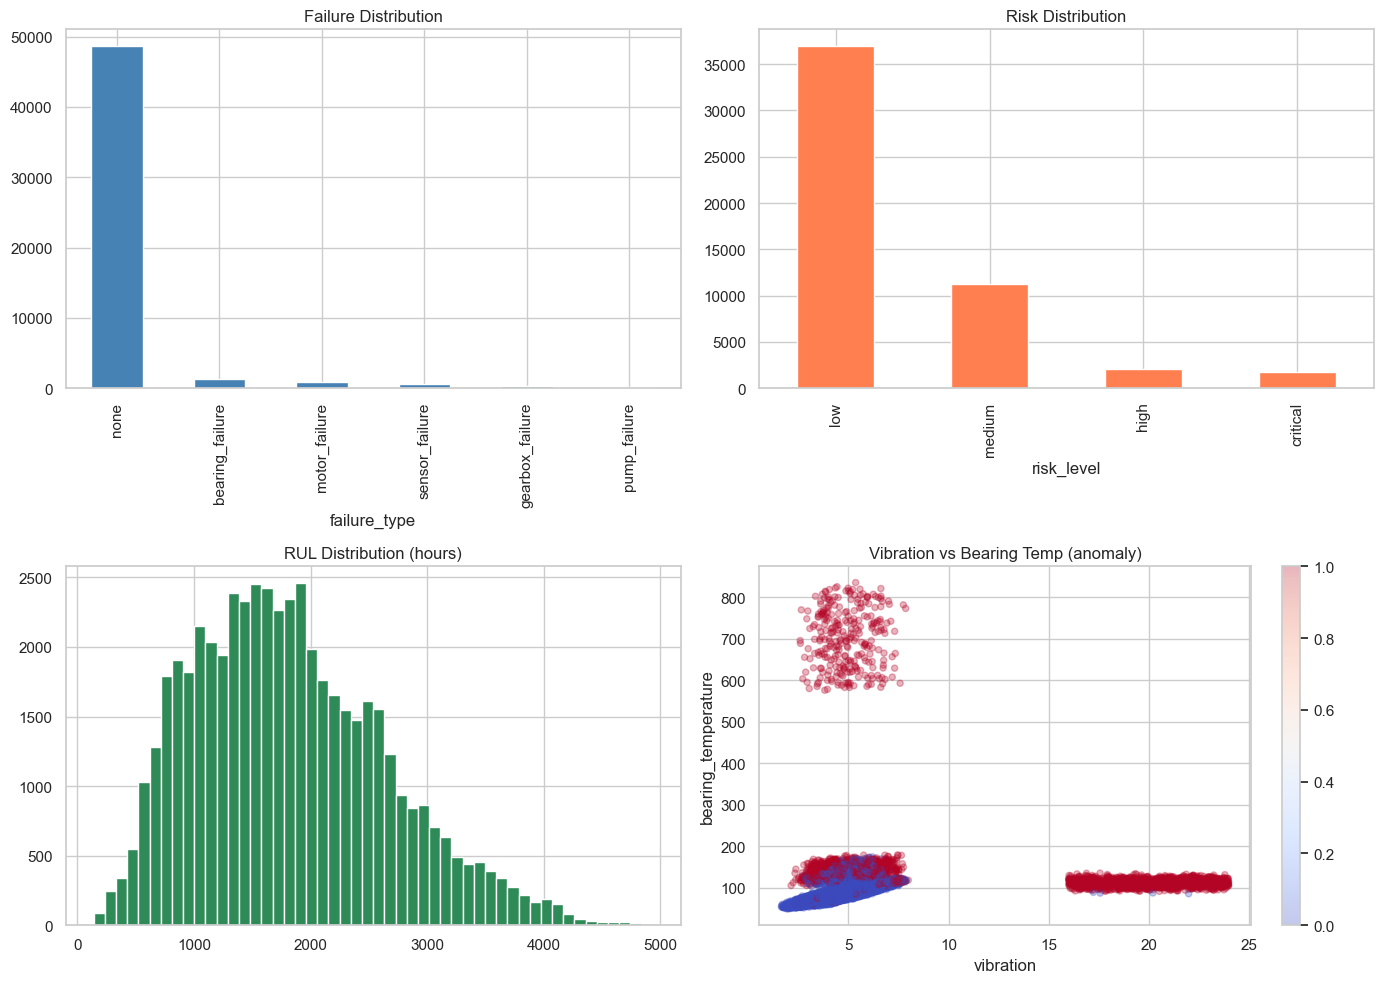

,temperature,vibration,pressure,current,voltage,rpm,flow_rate,power_consumption,oil_level,bearing_temperature,motor_temperature,gearbox_temperature,operating_hours,maintenance_days_ago,production_load,downtime_cost_per_hour,anomaly_score,remaining_useful_life_hours,target
0,75.869500,22.809053,0.847940,38.195107,400.00018,1776.6383,0.000000,13.450745,69.414650,102.87926,112.89774,98.84306,6322.6704,82.55373,0.458362,24439.314,0.904978,326.79126,bearing_failure
1,94.604095,21.679237,0.545200,37.697502,399.28397,1737.4702,0.000000,13.289703,65.791855,123.30489,135.54604,117.40179,6333.6704,83.01206,0.470008,24439.314,0.941013,319.92273,bearing_failure
2,123.484955,4.731493,0.707929,82.919700,399.82580,1770.9457,1.653304,13.819108,65.118140,152.33319,167.47397,151.07857,6342.6704,83.38706,0.476326,24439.314,0.824451,703.26074,motor_failure
3,77.241410,16.013287,0.500000,37.839916,401.29498,1773.6661,0.000000,13.476733,64.787346,105.31257,117.55489,107.36536,6353.6704,83.84539,0.479326,24439.314,0.843568,622.30740,bearing_failure
4,86.803910,20.553696,0.737030,39.603360,402.00348,1729.6390,0.000000,14.136990,65.745445,121.17719,133.72359,115.04222,6355.6704,83.92873,0.479280,24439.314,0.928941,387.30050,bearing_failure


In [2]:
# --- Data Engineering & EDA ---
master = pd.read_csv(MASTER / "industrial_master.csv", parse_dates=["timestamp"])
print(f"Master records: {len(master):,} | Assets: {master['equipment_id'].nunique()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
master["failure_type"].value_counts().plot(kind="bar", ax=axes[0,0], title="Failure Distribution", color="steelblue")
master["risk_level"].value_counts().plot(kind="bar", ax=axes[0,1], title="Risk Distribution", color="coral")
axes[1,0].hist(master["remaining_useful_life_hours"], bins=50, color="seagreen", edgecolor="white")
axes[1,0].set_title("RUL Distribution (hours)")
master.plot.scatter(x="vibration", y="bearing_temperature", c=master["is_anomaly"], cmap="coolwarm", alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Vibration vs Bearing Temp (anomaly)")
plt.tight_layout()
plt.savefig(DATASETS / MODEL_KEY / "eda_overview.png", dpi=120)
plt.show()

if TRAIN_CSV.exists():
    try:
        from IPython.display import display
        display(pd.read_csv(TRAIN_CSV).head())
    except ImportError:
        print(pd.read_csv(TRAIN_CSV).head())

## 3. Model Training & Evaluation

                 precision    recall  f1-score   support

bearing_failure       1.00      1.00      1.00       218
gearbox_failure       1.00      1.00      1.00        46
  motor_failure       1.00      0.99      1.00       194
   pump_failure       1.00      1.00      1.00        44
 sensor_failure       0.99      1.00      1.00       102

       accuracy                           1.00       604
      macro avg       1.00      1.00      1.00       604
   weighted avg       1.00      1.00      1.00       604

Accuracy: 0.998 | F1: 0.999


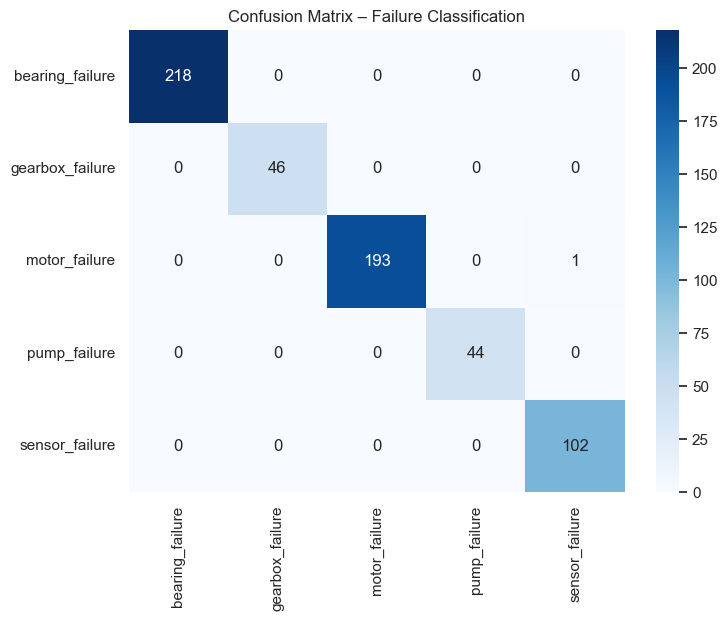

['c:\\Users\\ASUS\\Downloads\\tata-steel-round -2\\industrial-agentic-maintenance-ai\\backend\\artifacts\\xgboost_failure.joblib']

In [3]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

X_train, y_train = train_npz["X"], train_npz["y"]
X_test, y_test = test_npz["X"], test_npz["y"]
le = LabelEncoder(); y_tr = le.fit_transform(y_train); y_te = le.transform(y_test)
clf = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric="mlogloss")
clf.fit(X_train, y_tr)
pred = clf.predict(X_test)
print(classification_report(y_te, pred, target_names=le.classes_))
print(f"Accuracy: {accuracy_score(y_te,pred):.3f} | F1: {f1_score(y_te,pred,average='macro'):.3f}")

cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Confusion Matrix – Failure Classification")
plt.savefig(DATASETS / MODEL_KEY / "confusion_matrix.png", dpi=120)
plt.show()

joblib.dump({"classifier": clf, "label_encoder": le}, ARTIFACTS / "xgboost_failure.joblib")

## 4. Pipeline Evaluation Metrics

In [4]:
metrics_path = EVAL / "metrics.json"
if metrics_path.exists():
    all_metrics = json.loads(metrics_path.read_text())
    print(json.dumps(all_metrics.get(MODEL_KEY, {}), indent=2))
else:
    print("Run: python scripts/generate_synthetic_data.py --skip-train  to generate metrics")

{
  "accuracy": 0.9983443708609272,
  "precision_macro": 0.9980582524271846,
  "recall_macro": 0.9989690721649485,
  "f1_macro": 0.9985075943782693,
  "confusion_matrix": [
    [
      218,
      0,
      0,
      0,
      0
    ],
    [
      0,
      46,
      0,
      0,
      0
    ],
    [
      0,
      0,
      193,
      0,
      1
    ],
    [
      0,
      0,
      0,
      44,
      0
    ],
    [
      0,
      0,
      0,
      0,
      102
    ]
  ],
  "classification_report": {
    "bearing_failure": {
      "precision": 1.0,
      "recall": 1.0,
      "f1-score": 1.0,
      "support": 218.0
    },
    "gearbox_failure": {
      "precision": 1.0,
      "recall": 1.0,
      "f1-score": 1.0,
      "support": 46.0
    },
    "motor_failure": {
      "precision": 1.0,
      "recall": 0.9948453608247423,
      "f1-score": 0.9974160206718347,
      "support": 194.0
    },
    "pump_failure": {
      "precision": 1.0,
      "recall": 1.0,
      "f1-score": 1.0,
      "support"

## 5. Production Deployment

Artifact saved to `backend/artifacts/`. Restart API after retraining:
```bash
cd backend && uvicorn main:app --reload --port 8000
```